# P9 - Corrélation Quanti / Quanti

---

### 🎯 Objectif

**Construire une fonction générique pour tester statistiquement la corrélation entre 2 variables quantitavies (exemple : âge des clients ↔ Montant total des achats)**

### 📚 Ce que vous allez apprendre

| Étape | Méthode | Outil |
|-------|---------|-------|
| Visualiser | Nuage de points | `plotly` / `seaborn` |
| Vérifier la normalité | Test de Shapiro-Wilk | `scipy.stats.shapiro` |
| Tester | Pearson (si normal) ou Spearman (sinon) | `scipy.stats` |
| Interpréter | Coefficient r, p-value | Grille de lecture |

---

### ⚠️ Choix du test selon la normalité

| Condition | Test à utiliser | Caractéristiques |
|-----------|-----------------|------------------|
| Données normales | **Pearson** | Détecte les relations **linéaires** |
| Données non normales | **Spearman** | Détecte les relations **monotones** (pas forcément linéaires) |

---

## 1. Configuration et chargement des données

In [2]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Bibliothèques statistiques
from scipy import stats
from scipy.stats import shapiro, normaltest, pearsonr, spearmanr

# Configuration
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Bibliothèques chargées avec succès !")

✅ Bibliothèques chargées avec succès !


In [3]:
# Charger les données préparées
DATA_PATH = "../data/processed/"

df = pd.read_csv(DATA_PATH + "transactions_enrichies.csv")
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Données chargées : {len(df):,} transactions")
print(f"\nColonnes disponibles : {list(df.columns)}")

✅ Données chargées : 687,534 transactions

Colonnes disponibles : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth', 'segment_client', 'age_client']


---

## 2. Préparation des données

### 📚 Problème

Nos données sont au niveau **transaction** (une ligne = un achat).

Pour analyser la corrélation Âge ↔ Montant total, nous devons **agréger par client** :
- Chaque client a **un seul âge**
- Chaque client a **un montant total** (somme de ses achats)

In [4]:
# Utiliser uniquement les clients B2C
df = df[df['segment_client'] == 'B2C']

In [5]:
print(f"\nÂge min : {df['age_client'].min()} ans")
print(f"Âge max : {df['age_client'].max()} ans")
print(f"Âge moyen : {df['age_client'].mean():.1f} ans")


Âge min : 22 ans
Âge max : 97 ans
Âge moyen : 48.2 ans


In [6]:
# Agréger par client
clients = df.groupby('client_id').agg({
    'age_client': 'first',           # L'âge est le même pour toutes les transactions d'un client
    'sex': 'first',           # Idem pour le sexe
    'price': 'sum',           # Montant total des achats
    'id_prod': 'count'        # Nombre de transactions
}).reset_index()

# Renommer les colonnes
clients.columns = ['client_id', 'age', 'sex', 'montant_total', 'nb_transactions']

print(f"✅ Données agrégées : {len(clients):,} clients")
display(clients.head())

✅ Données agrégées : 8,596 clients


,client_id,age,sex,montant_total,nb_transactions
0,c_1,71,m,629.02,43
1,c_10,70,m,1353.60,58
2,c_100,34,m,254.85,8
3,c_1000,60,f,2291.88,126
4,c_1001,44,m,1823.85,103


In [7]:
# Statistiques descriptives
print("📊 STATISTIQUES DESCRIPTIVES")
print("=" * 50)
display(clients[['age', 'montant_total']].describe().round(2))

📊 STATISTIQUES DESCRIPTIVES


,age,montant_total
count,8596.00,8596.00
mean,47.74,1296.34
std,16.91,958.40
min,22.00,6.31
25%,34.00,562.64
50%,47.00,1045.58
75%,60.00,1796.02
max,97.00,5285.82


## 3. Fonction générique de corrélation quanti-quanti

### 3.1 Vérification préliminaire

In [8]:
def verification_donnees_utilisateur(df, var1, var2):
    """
    Vérifie les données de l'utilisateur pour s'assurer de la bonne exécution des tests statistiques.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données.
        var1 (str): Nom de la première variable.
        var2 (str): Nom de la deuxième variable.
        
    Returns:
        dict: Dictionnaire contenant les résultats de la vérification.
        - 'type_df': Type de DataFrame (pandas ou plotly)
        - 'dtype_var1': Data Type de la variable 1
        - 'dtype_var2': Data Type de la variable 2
        - 'shape': Forme du DataFrame
    """
    
    resultats = {
        'type_df': type(df).__name__,
        'dtype_var1': df[var1].dtype if var1 in df.columns else None,
        'dtype_var2': df[var2].dtype if var2 in df.columns else None,
        'shape': df.shape
    }
    
    return resultats


In [ ]:
verification_donnees_utilisateur(df=clients, var1='age', var2='montant_total')

{'type_df': 'DataFrame',
 'dtype_var1': dtype('int64'),
 'dtype_var2': None,
 'shape': (8596, 5)}

### 3.2 Test de normalité des variables quantitatives

#### 📚 Pourquoi tester la normalité ?

Le test de **Pearson** suppose que les variables suivent une **distribution normale** (en forme de cloche).

Si ce n'est pas le cas, on utilise le test de **Spearman** qui n'a pas cette exigence.

#### Tests disponibles

| Test | Usage | Taille recommandée |
|------|-------|--------------------|
| **Shapiro-Wilk** | Le plus puissant | n < 5000 |
| **D'Agostino-Pearson** | Alternative | n > 20 |
| **Kolmogorov-Smirnov** | Grands échantillons | n > 50 |

#### Fonction de test statistique

In [10]:
def verification_normalite(df, var):
    """
    Vérifie la normalité d'une variable à l'aide du test de Shapiro-Wilk.
    Affiche les résultats et les graphiques associés.
    """
    
    # Test de Shapiro-Wilk
    stat, p_shapiro = shapiro(df[var])
    
    # Retours des résultats
    resultats = {
        'shapiro_stat': stat,
        'shapiro_p_value': p_shapiro
    }
    
    return resultats


In [31]:
verification_normalite(df=clients, var='age')

c:\Users\RémiJulien\OneDrive\Documents\DcidConsulting\2.Prestation\3.Formation\3.Production\2025_GRETA DEV IA_P5\OCR_Projet_9\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


{'shapiro_stat': np.float64(0.9697306402580121),
 'shapiro_p_value': np.float64(4.615340399594916e-39)}

#### Fonction d'évaluation graphique Q-Q Plot

In [12]:
def plot_normalite(df, var):
    """
    Affiche 2 graphiques pour évaluer la distribution et la normalité des variables du dataset pour une variable donnée.
    - Graphique 1 : Histogramme avec courbe de densité
    - Graphique 2 : Q-Q plot pour évaluer la normalité
    """
    
    # Fenetre graphique
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution de la variable               
    axes[0].hist(df[var], bins=30, edgecolor='white', color='#2196F3', alpha=0.7)
    axes[0].axvline(df[var].mean(), color='red', linestyle='--', label=f"Moyenne = {df[var].mean():.1f}")
    axes[0].axvline(df[var].median(), color='orange', linestyle='--', label=f"Médiane = {df[var].median():.1f}")
    axes[0].set_title(f'Distribution de la variable {var}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(f'{var}')
    axes[0].set_ylabel('Fréquence')
    axes[0].legend()

    # Q-Q plot de la variable
    stats.probplot(df[var], dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot : {var}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()    

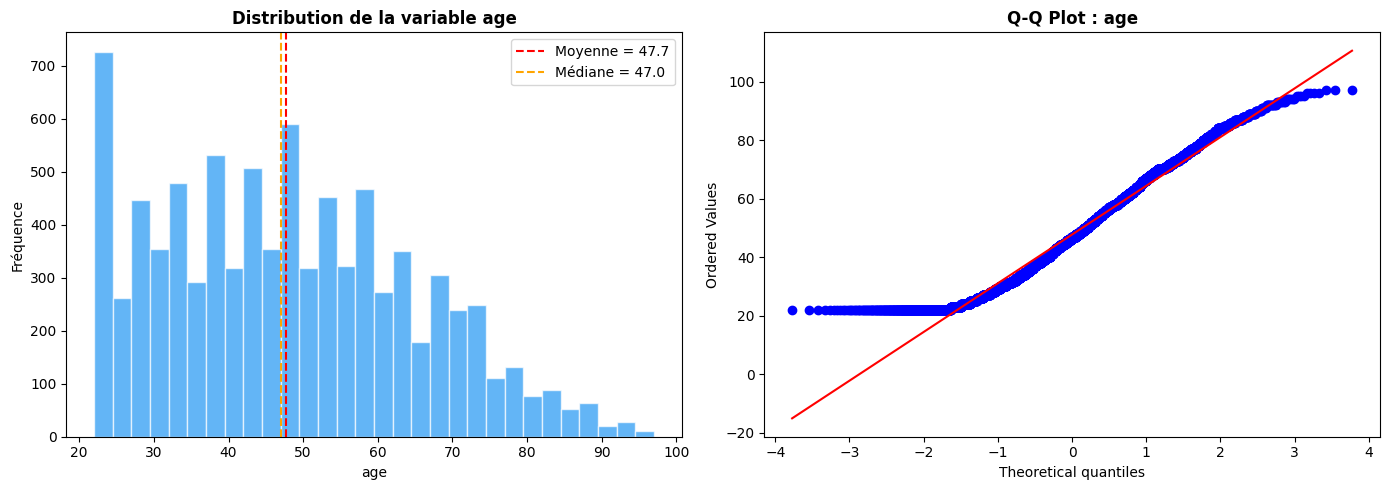

In [33]:
plot_normalite(df=clients, var='age')


**📖 Comment lire un Q-Q Plot (quantile-quantile) ?**

| Observation | Interprétation |
|-------------|----------------|
| Points **alignés** sur la diagonale | Distribution normale ✅ |
| Points **en S** | Queues plus lourdes que la normale |
| Points **courbés vers le haut** à droite | Asymétrie à droite (queue longue) |
| Points **courbés vers le bas** à gauche | Asymétrie à gauche |

### 3.3 Test statistique de correlation

#### 📚 Les deux tests

| Test | Ce qu'il mesure | Coefficient | Condition |
|------|-----------------|-------------|----------|
| **Pearson** | Corrélation **linéaire** | r | Normalité |
| **Spearman** | Corrélation **monotone** | ρ (rho) | Aucune |

#### Interprétation du coefficient

| Valeur | Interprétation |
|--------|----------------|
| r = +1 | Corrélation positive parfaite |
| r > +0.7 | Corrélation positive forte |
| r = +0.3 à +0.7 | Corrélation positive modérée |
| r = 0 à +0.3 | Corrélation positive faible |
| r = 0 | Aucune corrélation |
| r < 0 | Corrélation négative (même logique) |

#### Corrélation Pearson

In [14]:
def correlation_pearson(df, var1, var2):
    """
    Calcule la corrélation de Pearson entre deux variables quantitatives.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données.
        var1 (str): Nom de la première variable.
        var2 (str): Nom de la deuxième variable.
        
    Returns:
        dict: Dictionnaire contenant les résultats du test de corrélation de Pearson.
        - 'correlation_coefficient': Coefficient de corrélation
        - 'p_value': Valeur p du test
    """
    
    # Calcul de la corrélation de Pearson
    correlation_coefficient, p_value = pearsonr(df[var1], df[var2])
    
    # Retours des résultats
    resultats = {
        'correlation_coefficient': correlation_coefficient,
        'p_value': p_value
    }
    
    return resultats

In [34]:
correlation_pearson(df=clients, var1='age', var2='montant_total')

{'correlation_coefficient': np.float64(-0.18756654332685185),
 'p_value': np.float64(6.663511559772089e-69)}

#### Correlation Spearman

In [16]:
def correlation_spearman(df, var1, var2):
    """
    Calcule la corrélation de Spearman entre deux variables.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données.
        var1 (str): Nom de la première variable.
        var2 (str): Nom de la deuxième variable.
        
    Returns:
        dict: Dictionnaire contenant les résultats du test de corrélation de Spearman.
        - 'correlation_coefficient': Coefficient de corrélation de Spearman
        - 'p_value': P-value associée
    """
    
    corr, p_value = spearmanr(df[var1], df[var2])
    
    # Retours des résultats
    resultats = {
        'correlation_coefficient': corr,
        'p_value': p_value
    }
    
    return resultats

In [17]:
correlation_spearman(df=clients, var1='age', var2='montant_total')

{'correlation_coefficient': np.float64(-0.18453804793783096),
 'p_value': np.float64(1.0212910436382563e-66)}

### 3.4 Graphique de corrélation

In [18]:
def correlation_scatter_plot(df, var1, var2):
    """
    Affiche un scatter plot Plotly pour visualiser la relation entre deux variables quantitatives.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données.
        var1 (str): Nom de la première variable.
        var2 (str): Nom de la deuxième variable.
    """
    
    #fig = px.scatter(df, x=var1, y=var2, trendline="ols", title=f"Scatter Plot de {var1} vs {var2}")
    
    # Nuage de points avec distributions marginales (jointplot)
    fig = px.scatter(
        df,
        x=var1,
        y=var2,
        trendline="ols",
        marginal_x='histogram',
        marginal_y='histogram',
        title=f'Distribution conjointe : {var1} et {var2}',
        labels={var1: f'{var1}', var2: f'{var2}'},
        opacity=0.5
    )

    fig.update_layout(template='plotly_white', height=600)
    fig.show()

In [19]:
correlation_scatter_plot(df=clients, var1='age', var2='montant_total')

### 3.5 Fonction globale

In [ ]:
def correlation_quanti_quanti(df, var1, var2, seuil=0.05):
    """
    Calcule et affiche la corrélation entre deux variables quantitatives.
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable.
        var2 (str): Le nom de la deuxième variable.
    """
    
    # Initialisation de la fonction ---------------------------------------
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION")
    print("=" * 70)
    
    
    # Step 1 : vérification préliminaire des données ----------------------
    print("\n" + "-" * 70)
    verif = verification_donnees_utilisateur(df=df, var1=var1, var2=var2)
    print(f"🔍 Analyse de la corrélation entre '{var1}' (type : {verif['dtype_var1']}) et '{var2}' (type : {verif['dtype_var2']})")
    
    print(f"📊 Type du dataset : {verif['type_df']}")
    print(f"📊 Forme du DataFrame : {verif['shape']}")
    
    if verif['type_df'] == 'DataFrame' and verif['dtype_var1'] in ['int64', 'float64'] and verif['dtype_var2'] in ['int64', 'float64'] and verif['shape'][0] > 2:
        print(f"✅ Vérification des données : OK, les variables sont quantitatives et le dataset est suffisant pour l'analyse.")
    else:
        print(f"❌ Vérification des données : Les variables doivent être quantitatives (int64 ou float64) et le dataset doit contenir plus de 2 lignes pour effectuer une analyse de corrélation.")
        return
    
    
    # Step 2 : Vérification de la normalité des variables ----------------------
    print("\n" + "-" * 70)
    print(f"🔍 Vérification de la normalité des variables '{var1}' et '{var2}'")
    normalite_var1 = verification_normalite(df=df, var=var1)
    normalite_var2 = verification_normalite(df=df, var=var2)
    
    # Affichage des résultats de normalité et graphique pour la variable 1
    print(f"P-value de Shapiro-Wilk pour '{var1}' : {normalite_var1['shapiro_p_value']:.4f}")
    plot_normalite(df=df, var=var1)
    
    # Affichage des résultats de normalité et graphique pour la variable 1
    print(f"P-value de Shapiro-Wilk pour '{var2}' : {normalite_var2['shapiro_p_value']:.4f}")
    plot_normalite(df=df, var=var2)
    
    if normalite_var1['shapiro_p_value'] > seuil and normalite_var2['shapiro_p_value'] > seuil:
        print(f"✅ Les deux variables suivent une distribution normale (p > {seuil}).")
        normalite = True
    else:
        print(f"⚠️ Au moins une des variables ne suit pas une distribution normale (p <= {seuil}).")
        normalite = False


    # Step 3 : Calcul de la corrélation --------------------------------------
    print("\n" + "-" * 70)
    print(f"🔍 Calcul de la corrélation entre '{var1}' et '{var2}'")
    
    if normalite:
        print(f"📊 Les deux variables sont normales, utilisation de la corrélation de Pearson.")
        resultats_correlation = correlation_pearson(df=df, var1=var1, var2=var2)
    else:
        print(f"⚠️ Au moins une des variables ne suit pas une distribution normale, utilisation de la corrélation de Spearman.")
        resultats_correlation = correlation_spearman(df=df, var1=var1, var2=var2)
    
    print(f"📊 Coefficient de corrélation : {resultats_correlation['correlation_coefficient']:.4f}")
    print(f"📊 P-value : {resultats_correlation['p_value']:.4f}")
    
    if resultats_correlation['p_value'] < seuil:
        print(f"✅ La corrélation est statistiquement significative (p < {seuil}).")
    else:
        print(f"⚠️ La corrélation n'est pas statistiquement significative (p >= {seuil}).")
    
    
    # Step 4 : Visualisation de la corrélation --------------------------------------
    print("\n" + "-" * 70) 
    print(f"🔍 Visualisation de la relation entre '{var1}' et '{var2}'")
    correlation_scatter_plot(df=df, var1=var1, var2=var2)#['plot'].show()
    
    
    # Step 5 : Rapport & Conclusion --------------------------------------
    print("\n" + "=" * 70)
    print(f"📊 RAPPORT DE CORRÉLATION ENTRE '{var1}' ET '{var2}'")
    print("=" * 70)
    print(f"🔍 Type de corrélation utilisée : {'Pearson' if normalite else 'Spearman'}")
    print(f"📊 Coefficient de corrélation : {resultats_correlation['correlation_coefficient']:.4f}")
    print(f"📊 P-value : {resultats_correlation['p_value']:.4f}")
    if resultats_correlation['p_value'] < seuil:
        print(f"✅ Conclusion : Il existe une corrélation statistiquement significative entre '{var1}' et '{var2}' (p < {seuil}).")
    else:
        print(f"⚠️ Conclusion : Il n'existe pas de corrélation statistiquement significative entre '{var1}' et '{var2}' (p >= {seuil}).")


📊 ANALYSE DE CORRÉLATION

----------------------------------------------------------------------
🔍 Analyse de la corrélation entre 'age' (type : int64) et 'montant_total' (type : float64)
📊 Type du dataset : DataFrame
📊 Forme du DataFrame : (8596, 5)
✅ Vérification des données : OK, les variables sont quantitatives et le dataset est suffisant pour l'analyse.

----------------------------------------------------------------------
🔍 Vérification de la normalité des variables 'age' et 'montant_total'
P-value de Shapiro-Wilk pour 'age' : 0.0000


c:\Users\RémiJulien\OneDrive\Documents\DcidConsulting\2.Prestation\3.Formation\3.Production\2025_GRETA DEV IA_P5\OCR_Projet_9\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


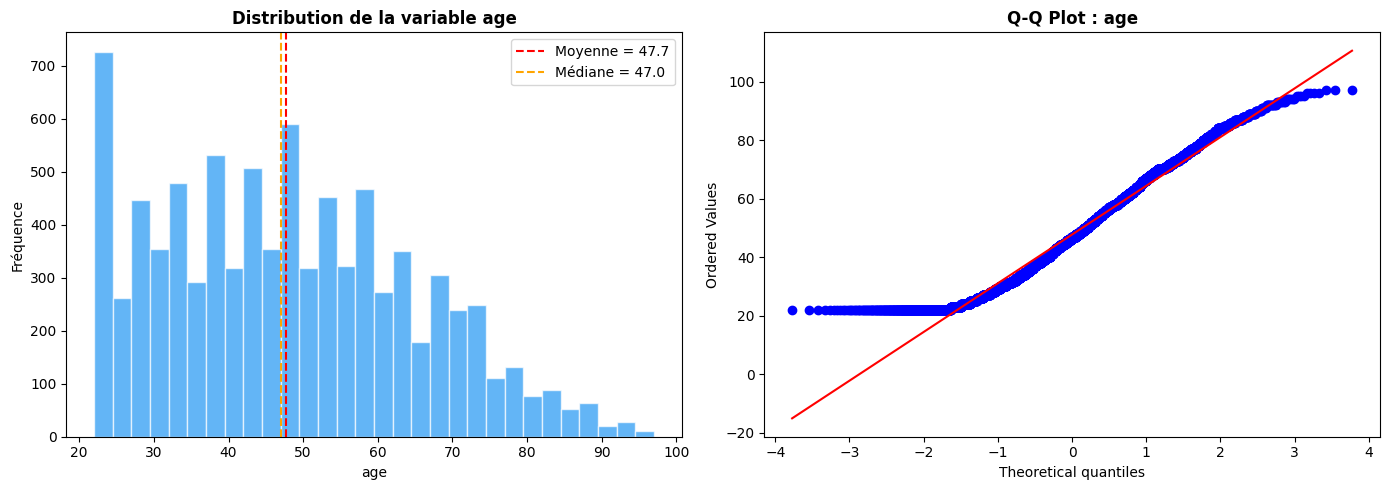

P-value de Shapiro-Wilk pour 'montant_total' : 0.0000


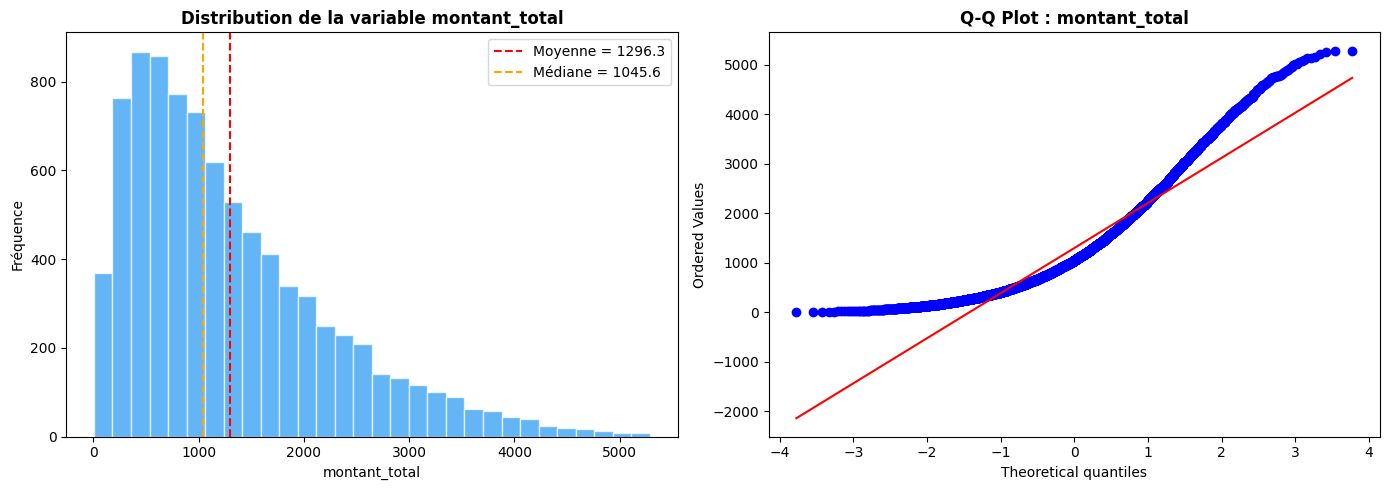

⚠️ Au moins une des variables ne suit pas une distribution normale (p <= 0.05).

----------------------------------------------------------------------
🔍 Calcul de la corrélation entre 'age' et 'montant_total'
⚠️ Au moins une des variables ne suit pas une distribution normale, utilisation de la corrélation de Spearman.
📊 Coefficient de corrélation : -0.1845
📊 P-value : 0.0000
✅ La corrélation est statistiquement significative (p < 0.05).

----------------------------------------------------------------------
🔍 Visualisation de la relation entre 'age' et 'montant_total'



📊 RAPPORT DE CORRÉLATION ENTRE 'age' ET 'montant_total'
🔍 Type de corrélation utilisée : Spearman
📊 Coefficient de corrélation : -0.1845
📊 P-value : 0.0000
✅ Conclusion : Il existe une corrélation statistiquement significative entre 'age' et 'montant_total' (p < 0.05).


In [28]:
#correlation_spearman(df=clients, var1='age', var2='montant_total')
correlation_quanti_quanti(df=clients, var1='age', var2='montant_total')

---

## 4. Récapitulatif des apprentissages 📚

### Ce que vous avez appris

| Étape | Code clé | Ce que ça fait |
|-------|----------|----------------|
| Visualiser | `px.scatter(trendline='ols')` | Nuage de points + régression |
| Test normalité | `shapiro(data)` | Retourne stat, p-value |
| Q-Q plot | `stats.probplot(data, plot=ax)` | Visualiser la normalité |
| Pearson | `pearsonr(x, y)` | Corrélation linéaire |
| Spearman | `spearmanr(x, y)` | Corrélation monotone |

### Arbre de décision

```
Variables quantitatives ?
        │
        ▼
Test de normalité (Shapiro-Wilk)
        │
        ├── Les deux normales → PEARSON
        │
        └── Au moins une non normale → SPEARMAN
```

### Grilles d'interprétation

**Coefficient de corrélation (r ou ρ) :**

| Valeur absolue | Force |
|----------------|-------|
| < 0.1 | Négligeable |
| 0.1 - 0.3 | Faible |
| 0.3 - 0.5 | Modérée |
| 0.5 - 0.7 | Forte |
| > 0.7 | Très forte |

**p-value :**

| Valeur | Interprétation |
|--------|----------------|
| < 0.001 | Très hautement significatif |
| < 0.01 | Hautement significatif |
| < 0.05 | Significatif |
| ≥ 0.05 | Non significatif |

### Points clés à retenir

1. **Toujours tester la normalité** avant de choisir Pearson vs Spearman
2. **Visualiser d'abord** : le nuage de points révèle beaucoup
3. **Significatif ≠ fort** : une corrélation peut être significative mais faible
4. **Corrélation ≠ causalité** : un lien statistique ne prouve pas une relation de cause à effet
5. **Attention aux outliers** : ils peuvent fausser Pearson (Spearman est plus robuste)